<a href="https://colab.research.google.com/github/Carereen/image-processing/blob/main/Assignment7_Sec2_6853800122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys

Number of objects: 9


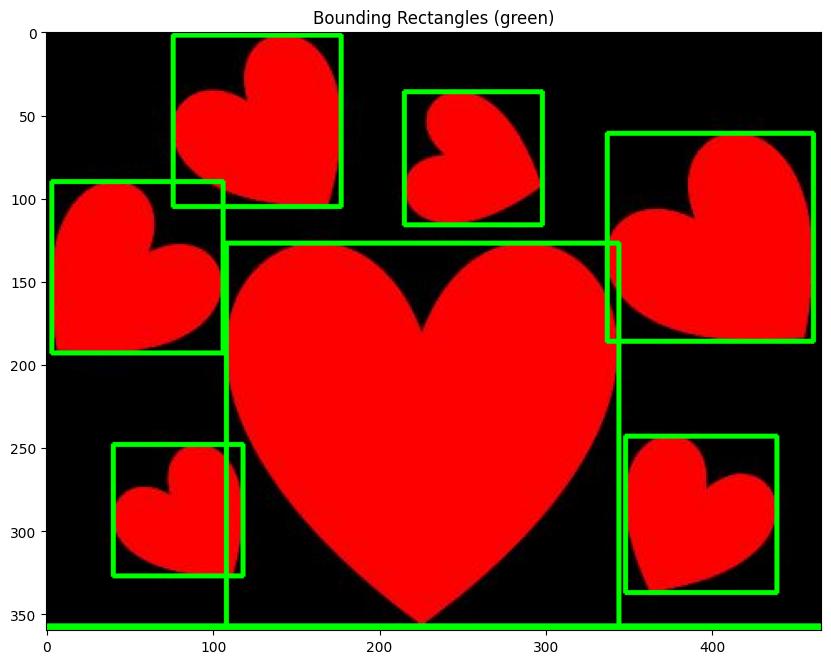

In [ ]:
import imutils

path = '/content/drive/MyDrive/2568-term2/image/week 7/'
image_name = 'red_heart.jpg'
image_color = cv2.imread(path + image_name, 1)

if image_color is None:
  print(f"image file not found. Please check the path: {path + image_name} .")
  sys.exit()

image_rgb = cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_color, cv2.COLOR_RGB2GRAY)

# THRESH_BINARY = วัตถุขาว, blackground = ดำ
# THRESH_BINARY_INV = object = ดำ, blackground = ขาว
thresh_val, image_binary = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

cnts = cv2.findContours(image_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

image_contours = image_rgb.copy()
cv2.drawContours(image_contours, cnts, -1, (0, 255, 0), 2)

img_rect = image_rgb.copy()
for c in cnts:
  (x, y, w, h) = cv2.boundingRect(c)
  cv2.rectangle(img_rect, (x, y), (x + w, y + h), (0, 255, 0) ,2)

print(f'Number of objects: {len(cnts)}')
fig = plt.figure(figsize = (10, 15))
plt.subplot(1, 1, 1)
plt.imshow(img_rect)
plt.title('Bounding Rectangles (green)')
plt.show()

Found 10 coins


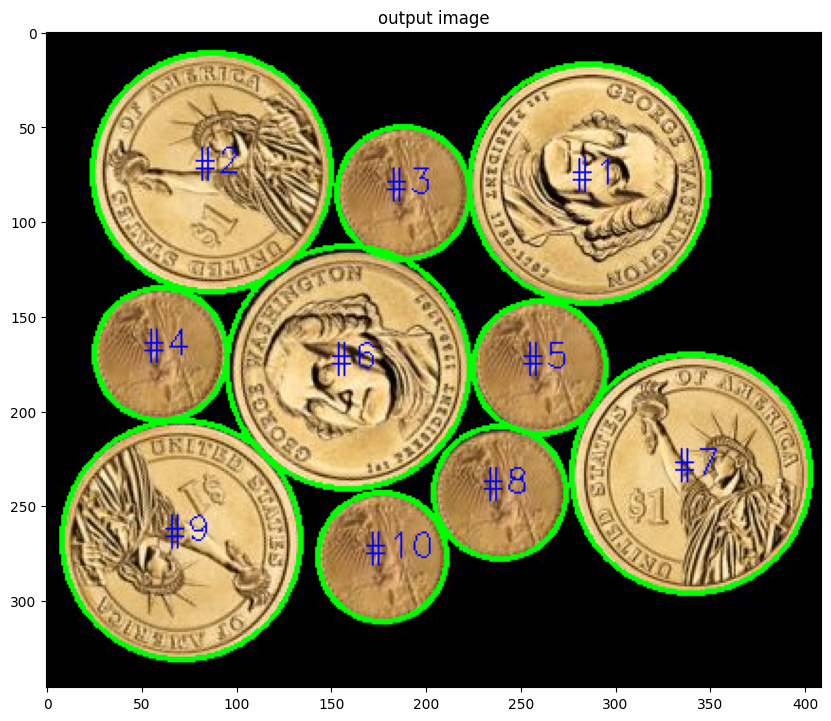

In [ ]:
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import imutils

image_name = 'coin2.jpg'
image_color = cv2.imread(path + image_name, 1)

if image_color is None:
  print(f"image file not found. Please check the path: {path + image_name} .")
  sys.exit()

image_rgb = cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB)

shifted = cv2.pyrMeanShiftFiltering(image_color, 21, 51)

gray = cv2.cvtColor(shifted, cv2.COLOR_BGR2GRAY)

gray = cv2.GaussianBlur(gray, (11, 11), 0)

ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

D = ndimage.distance_transform_edt(thresh)

coords = peak_local_max(D, min_distance = 25)

mask = np.zeros(D.shape, dtype = bool)
mask[tuple(coords.T)] = True
markers, _ = ndimage.label(mask)

labels = watershed(-D, markers, mask = (thresh > 0))

print('Found {} coins'.format(len(np.unique(labels)) -1))

for label in np.unique(labels):
  if label == 0:
    continue

  mask = np.zeros(gray.shape, dtype = 'uint8')
  mask[labels == label] = 255

  cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  cnts = imutils.grab_contours(cnts)
  c = max(cnts, key = cv2.contourArea)

  ((x, y), r) = cv2.minEnclosingCircle(c)
  cv2.circle(image_rgb, (int(x), int(y)), int(r), (0, 255, 0), 2)
  cv2.putText(image_rgb, '#{}'.format(label), (int(x) - 10, int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 1)

plt.figure(figsize = (10, 15))
plt.subplot(1, 1, 1)
plt.imshow(image_rgb, cmap = 'gray')
plt.title('output image')
plt.show()